<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [12]:
## Write your code here
# Display basic information about the dataframe
print(df.info())

# Display the shape of the dataset
print(f"\nDataset Shape: {df.shape}")

# Statistical summary of numerical columns
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None

Dataset Shape: (65437, 114)
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29393.000000    29411.000000    29450.000000     29448.00000   
mean         7.522140       10.060857

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [13]:
## Write your code here
# Identify missing values per column
print(df.isnull().sum())

# Option: Drop rows where critical columns (like JobSat) are missing
df.dropna(subset=['JobSat', 'Employment', 'YearsCodePro'], inplace=True)

# Option: Fill missing categorical values with the mode
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum().sum())

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

Missing values after handling:
524206


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [14]:
## Write your code here
# Distribution of Employment status
print("Employment Distribution:\n", df['Employment'].value_counts())

# Distribution of Job Satisfaction
print("\nJob Satisfaction Distribution:\n", df['JobSat'].value_counts())

# Professional Coding Experience distribution (Top 10)
print("\nYears of Professional Coding (Top 10):\n", df['YearsCodePro'].value_counts().head(10))

Employment Distribution:
 Employment
Employed, full-time                                                                                                                                                       21903
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                                                   2231
Independent contractor, freelancer, or self-employed                                                                                                                       1242
Employed, part-time                                                                                                                                                         531
Employed, full-time;Student, part-time                                                                                                                                      488
                                                                                   

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


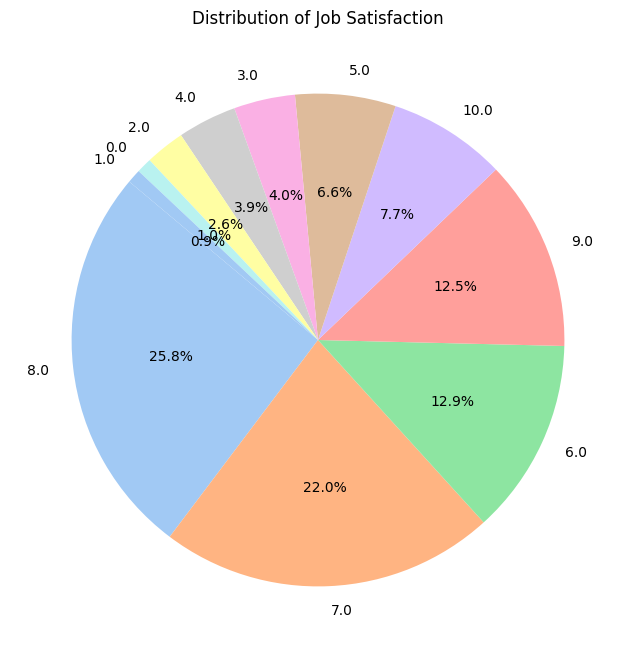

In [15]:
## Write your code here
# Data for pie chart
jobsat_counts = df['JobSat'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(jobsat_counts, labels=jobsat_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Job Satisfaction')
plt.show()

# Interpretation: This chart reveals the proportion of developers who are satisfied vs. dissatisfied. 
# Usually, 'Very satisfied' and 'Slightly satisfied' form the majority in this dataset.

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


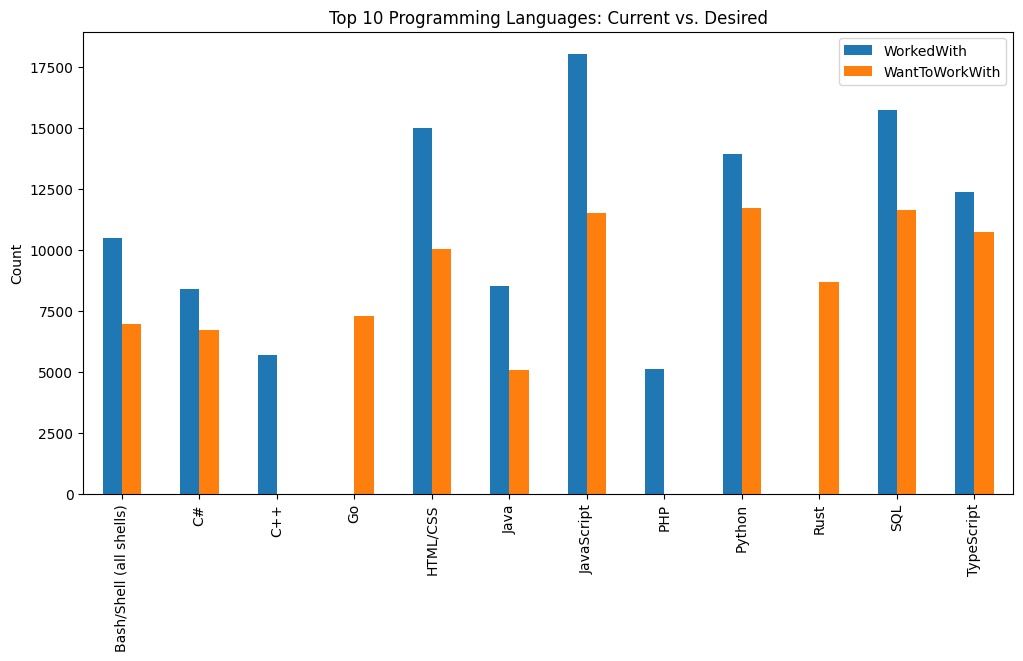

In [16]:
## Write your code here
# Function to split and count languages
def count_languages(column_name):
    return df[column_name].str.split(';', expand=True).stack().value_counts()

worked_languages = count_languages('LanguageHaveWorkedWith').head(10)
want_languages = count_languages('LanguageWantToWorkWith').head(10)

# Create a grouped bar chart
comparison_df = pd.DataFrame({'WorkedWith': worked_languages, 'WantToWorkWith': want_languages})
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Programming Languages: Current vs. Desired')
plt.ylabel('Count')
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


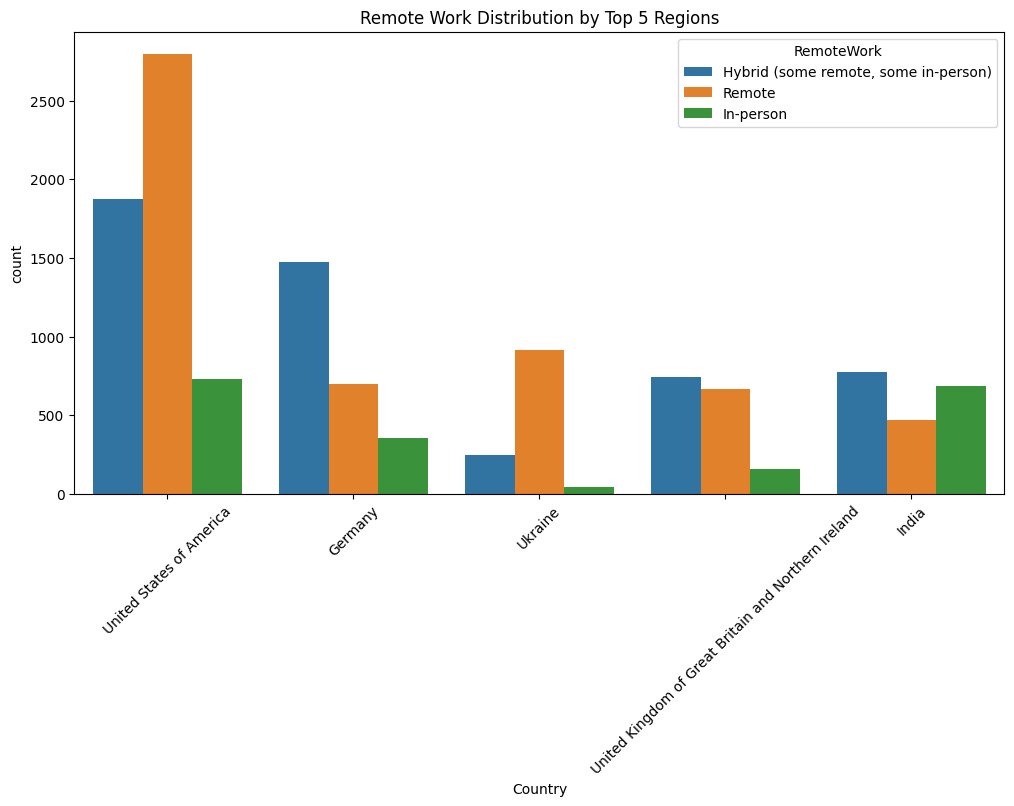

In [17]:
## Write your code here
# Visualizing RemoteWork by the top 5 Countries/Regions for clarity
top_countries = df['Country'].value_counts().nlargest(5).index
filtered_df = df[df['Country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.countplot(data=filtered_df, x='Country', hue='RemoteWork')
plt.title('Remote Work Distribution by Top 5 Regions')
plt.xticks(rotation=45)
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [18]:
## Write your code here
# Map JobSat to a numerical scale if not already done (e.g., JobSatPoints_1)
# Assuming 'YearsCodePro' is numeric; if not, convert it:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Calculate Spearman correlation (better for ordinal data like satisfaction)
correlation = df['JobSatPoints_1'].corr(df['YearsCodePro'], method='spearman')
print(f"Spearman Correlation between Job Satisfaction and Experience: {correlation:.4f}")

# Visualize with a regression plot
plt.figure(figsize=(10, 6))
sns.regplot(x='YearsCodePro', y='JobSatPoints_1', data=df, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Correlation: Experience vs. Job Satisfaction Score')
plt.show()

ModuleNotFoundError: No module named 'scipy'

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


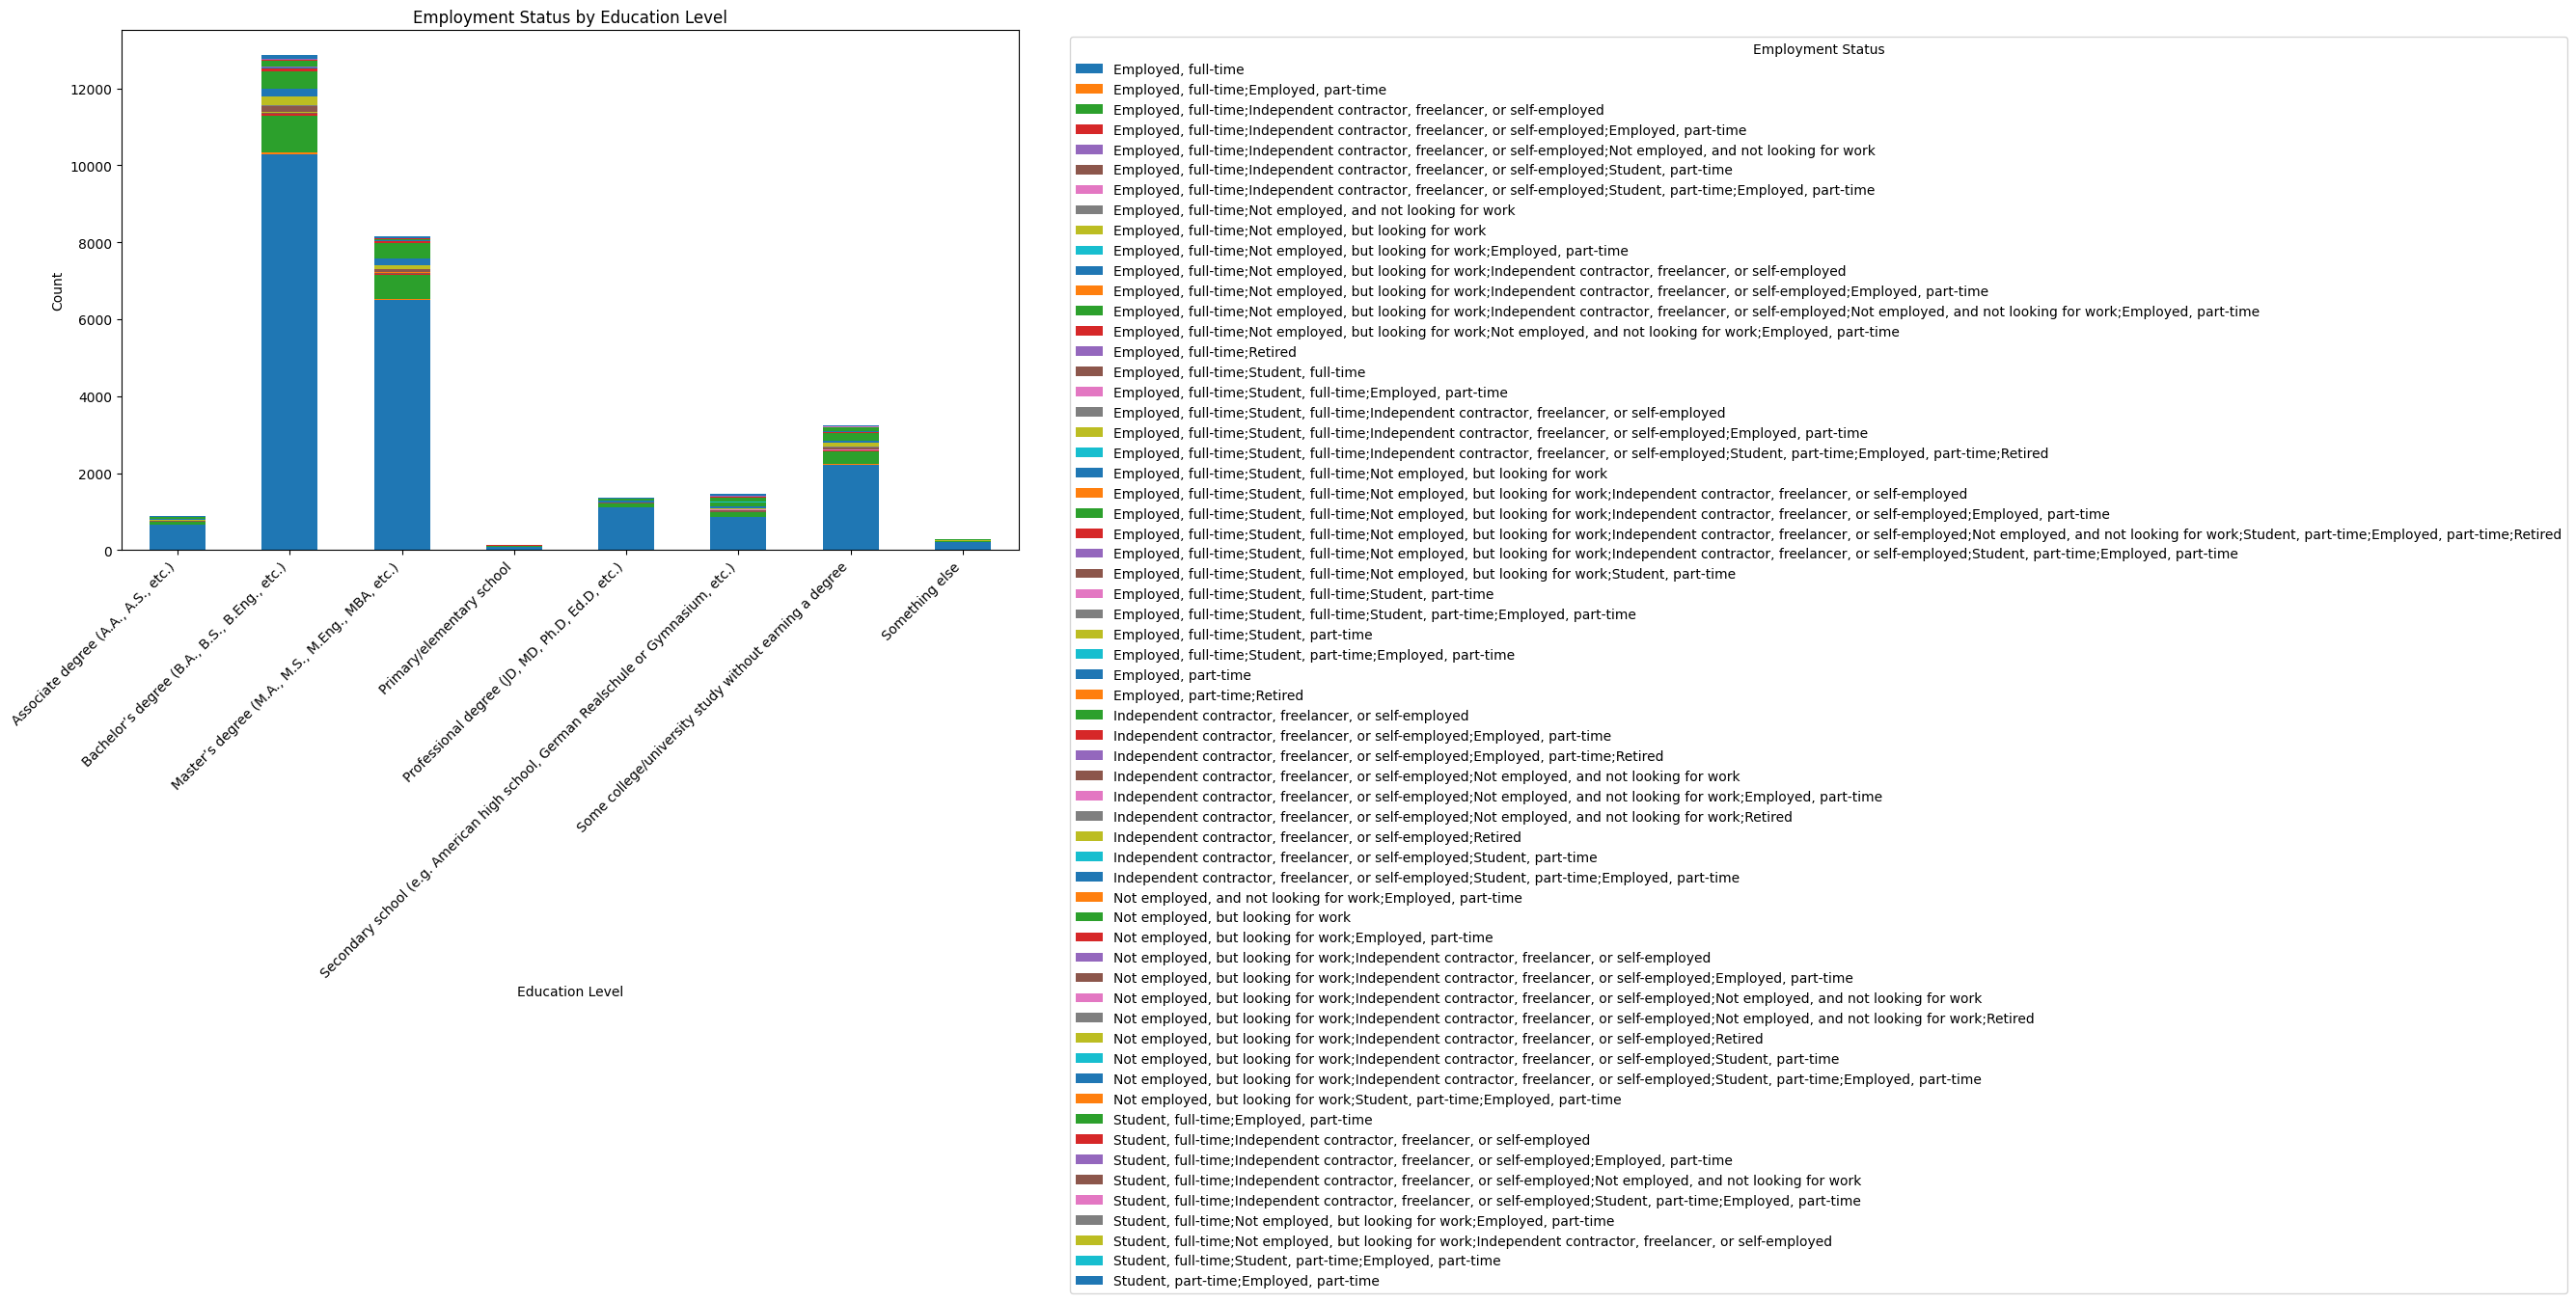

In [19]:
## Write your code here
# Create cross-tabulation
ct = pd.crosstab(df['EdLevel'], df['Employment'])

# Visualize with a stacked bar plot
ct.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Employment Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [20]:
## Write your code here
df.to_csv('Cleaned_StackOverflow_Data.csv', index=False)
print("File 'Cleaned_StackOverflow_Data.csv' has been saved successfully.")

File 'Cleaned_StackOverflow_Data.csv' has been saved successfully.


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
